# ToMe 实验结果可视化分析

本notebook支持：
- 多种数据源（JSON、CSV）
- 混合数据源（准确率和效率数据可以来自不同文件）
- 交互式可视化分析

In [1]:
# 导入必要的库
import matplotlib.pyplot as plt
import pandas as pd
import json
import numpy as np
from pathlib import Path
import seaborn as sns
from typing import Dict, List, Union, Optional
import warnings
warnings.filterwarnings('ignore')

# 设置matplotlib中文字体和样式
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")
sns.set_palette("husl")

print("✅ 库导入完成")

✅ 库导入完成


## 1. 数据加载器

支持加载JSON和CSV格式的数据

In [2]:
class FlexibleDataLoader:
    """灵活的数据加载器，支持JSON和CSV格式"""
    
    def __init__(self):
        self.data_cache = {}
    
    def load_json_results(self, file_path: str) -> Dict:
        """加载JSON格式的实验结果"""
        print(f"📁 Loading JSON data from: {file_path}")
        
        with open(file_path, 'r') as f:
            data = json.load(f)
        
        # 检查是否是新格式（包含metadata等字段）
        if 'results' in data:
            results = data['results']
            metadata = data.get('experiment_metadata', {})
            config = data.get('config', {})
        else:
            # 旧格式，直接是结果数据
            results = data
            metadata = {}
            config = {}
        
        # 转换为标准化的DataFrame格式
        df = self._json_to_dataframe(results)
        
        print(f"✅ Loaded {len(df)} data points from JSON")
        return {
            'dataframe': df,
            'metadata': metadata,
            'config': config,
            'source_type': 'json'
        }
    
    def load_csv_results(self, file_path: str) -> Dict:
        """加载CSV格式的实验结果"""
        print(f"📁 Loading CSV data from: {file_path}")
        
        df = pd.read_csv(file_path)
        
        # 标准化列名
        df = self._standardize_columns(df)
        
        print(f"✅ Loaded {len(df)} data points from CSV")
        return {
            'dataframe': df,
            'metadata': {},
            'config': {},
            'source_type': 'csv'
        }
    
    def _json_to_dataframe(self, results: Dict) -> pd.DataFrame:
        """将JSON结果转换为DataFrame"""
        data_rows = []
        
        for strategy_name, strategy_results in results.items():
            if not isinstance(strategy_results, dict) or 'error' in strategy_results:
                continue
                
            for r_key, result in strategy_results.items():
                if not r_key.startswith('r_') or 'error' in result:
                    continue
                    
                try:
                    r = int(r_key.split('_')[1])
                    accuracy_data = result.get('accuracy', {})
                    efficiency_data = result.get('efficiency', {})
                    
                    row = {
                        'Strategy': strategy_name,
                        'R': r,
                        'Top1_Acc': accuracy_data.get('top1_accuracy', np.nan),
                        'Top5_Acc': accuracy_data.get('top5_accuracy', np.nan),
                        'Avg_Time': efficiency_data.get('avg_time', np.nan),
                        'Throughput': efficiency_data.get('throughput', np.nan),
                        'Samples': accuracy_data.get('total_samples', np.nan),
                        'GPU_ID': accuracy_data.get('gpu_id', np.nan)
                    }
                    data_rows.append(row)
                    
                except (ValueError, KeyError, TypeError) as e:
                    print(f"⚠️ Error processing {strategy_name} {r_key}: {e}")
                    continue
        
        return pd.DataFrame(data_rows)
    
    def _standardize_columns(self, df: pd.DataFrame) -> pd.DataFrame:
        """标准化CSV列名"""
        # 定义列名映射
        column_mapping = {
            'strategy': 'Strategy',
            'r': 'R',
            'top1_accuracy': 'Top1_Acc',
            'top5_accuracy': 'Top5_Acc',
            'avg_time': 'Avg_Time',
            'throughput': 'Throughput',
            'samples': 'Samples',
            'gpu_id': 'GPU_ID'
        }
        
        # 重命名列
        for old_name, new_name in column_mapping.items():
            if old_name in df.columns:
                df = df.rename(columns={old_name: new_name})
        
        return df
    
    def merge_data_sources(self, accuracy_data: Dict, efficiency_data: Dict, 
                          merge_keys: List[str] = None) -> pd.DataFrame:
        """合并来自不同数据源的准确率和效率数据"""
        if merge_keys is None:
            merge_keys = ['Strategy', 'R']
        
        acc_df = accuracy_data['dataframe']
        eff_df = efficiency_data['dataframe']
        
        print(f"🔗 Merging accuracy data ({len(acc_df)} rows) with efficiency data ({len(eff_df)} rows)")
        
        # 选择需要的列
        acc_columns = merge_keys + ['Top1_Acc', 'Top5_Acc', 'Samples']
        eff_columns = merge_keys + ['Avg_Time', 'Throughput']
        
        # 确保列存在
        acc_available = [col for col in acc_columns if col in acc_df.columns]
        eff_available = [col for col in eff_columns if col in eff_df.columns]
        
        merged_df = pd.merge(
            acc_df[acc_available], 
            eff_df[eff_available], 
            on=[key for key in merge_keys if key in acc_df.columns and key in eff_df.columns],
            how='outer',
            suffixes=('_acc', '_eff')
        )
        
        print(f"✅ Merged data: {len(merged_df)} rows")
        return merged_df

# 创建数据加载器实例
data_loader = FlexibleDataLoader()
print("✅ 数据加载器初始化完成")

✅ 数据加载器初始化完成


## 2. 可视化工具类

In [3]:
class ResultVisualizer:
    """结果可视化工具"""
    
    def __init__(self, figsize=(15, 10)):
        self.figsize = figsize
        self.colors = plt.cm.Set1(np.linspace(0, 1, 10))
    
    def plot_accuracy_comparison(self, df: pd.DataFrame, save_path: str = None, 
                            yscale: str = 'linear', ylim_custom: tuple = None, ylim_custom_2: tuple = None):
        """
        绘制准确率对比图
        
        Parameters:
        - df: 数据DataFrame
        - save_path: 保存路径
        - yscale: y轴刻度类型 ('linear', 'log', 'symlog', 'logit')
        - ylim_custom: 自定义y轴范围，如 (0.7, 0.8)
        """
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=self.figsize)
        
        # Top-1准确率
        if 'Top1_Acc' in df.columns:
            for strategy in df['Strategy'].unique():
                strategy_data = df[df['Strategy'] == strategy].sort_values('R')
                ax1.plot(strategy_data['R'], strategy_data['Top1_Acc'], 
                        marker='o', linewidth=2, markersize=6, label=strategy)
            
            ax1.set_title('Top-1 Accuracy vs Token Reduction', fontsize=14, fontweight='bold')
            ax1.set_xlabel('R (tokens to remove)')
            ax1.set_ylabel('Top-1 Accuracy')
            ax1.legend()
            ax1.grid(True, alpha=0.3)
            
            # 设置y轴刻度
            ax1.set_yscale(yscale)
            
            # 设置y轴范围
            if ylim_custom:
                ax1.set_ylim(ylim_custom)
            elif yscale == 'linear':
                ax1.set_ylim([0, 1])
            elif yscale == 'log':
                # 对数刻度时，避免0值
                min_val = df['Top1_Acc'].min() * 0.9
                max_val = min(df['Top1_Acc'].max() * 1.1, 1.0)
                ax1.set_ylim([max(min_val, 0.001), max_val])
            elif yscale == 'logit':
                # logit刻度适用于0-1之间的概率值
                ax1.set_ylim([0.001, 0.999])
        
        # Top-5准确率
        if 'Top5_Acc' in df.columns:
            for strategy in df['Strategy'].unique():
                strategy_data = df[df['Strategy'] == strategy].sort_values('R')
                ax2.plot(strategy_data['R'], strategy_data['Top5_Acc'], 
                        marker='s', linewidth=2, markersize=6, label=strategy)
            
            ax2.set_title('Top-5 Accuracy vs Token Reduction', fontsize=14, fontweight='bold')
            ax2.set_xlabel('R (tokens to remove)')
            ax2.set_ylabel('Top-5 Accuracy')
            ax2.legend()
            ax2.grid(True, alpha=0.3)
            
            # 设置y轴刻度
            ax2.set_yscale(yscale)
            
            # 设置y轴范围
            if ylim_custom_2:
                ax2.set_ylim(ylim_custom_2)
            elif yscale == 'linear':
                ax2.set_ylim([0, 1])
            elif yscale == 'log':
                min_val = df['Top5_Acc'].min() * 0.9
                max_val = min(df['Top5_Acc'].max() * 1.1, 1.0)
                ax2.set_ylim([max(min_val, 0.001), max_val])
            elif yscale == 'logit':
                ax2.set_ylim([0.001, 0.999])
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"📊 Accuracy plots saved to {save_path}")
        
        plt.show()

    def plot_efficiency_comparison(self, df: pd.DataFrame, save_path: str = None,
                                 yscale: str = 'linear', ylim_custom: tuple = None):
        """绘制效率对比图"""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=self.figsize)
        
        # 推理时间
        if 'Avg_Time' in df.columns:
            for strategy in df['Strategy'].unique():
                strategy_data = df[df['Strategy'] == strategy].sort_values('R')
                ax1.plot(strategy_data['R'], strategy_data['Avg_Time'], 
                        marker='^', linewidth=2, markersize=6, label=strategy)
            
            ax1.set_title('Inference Time vs Token Reduction', fontsize=14, fontweight='bold')
            ax1.set_xlabel('R (tokens to remove)')
            ax1.set_ylabel('Inference Time (s)')
            ax1.legend()
            ax1.grid(True, alpha=0.3)
            ax1.set_yscale(yscale)
            
            if ylim_custom:
                ax1.set_ylim(ylim_custom)
            elif yscale == 'log':
                min_val = df['Avg_Time'].min() * 0.8
                max_val = df['Avg_Time'].max() * 1.2
                ax1.set_ylim([max(min_val, 0.001), max_val])
        
        # 吞吐量
        if 'Throughput' in df.columns:
            for strategy in df['Strategy'].unique():
                strategy_data = df[df['Strategy'] == strategy].sort_values('R')
                ax2.plot(strategy_data['R'], strategy_data['Throughput'], 
                        marker='d', linewidth=2, markersize=6, label=strategy)
            
            ax2.set_title('Throughput vs Token Reduction', fontsize=14, fontweight='bold')
            ax2.set_xlabel('R (tokens to remove)')
            ax2.set_ylabel('Throughput (images/sec)')
            ax2.legend()
            ax2.grid(True, alpha=0.3)
            ax2.set_yscale(yscale)
            
            if ylim_custom:
                ax2.set_ylim(ylim_custom)
            elif yscale == 'log':
                min_val = df['Throughput'].min() * 0.8
                max_val = df['Throughput'].max() * 1.2
                ax2.set_ylim([max(min_val, 1), max_val])
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"📊 Efficiency plots saved to {save_path}")
        
        plt.show()
    
    def plot_comprehensive_comparison(self, df: pd.DataFrame, save_path: str = None,
                                    yscale_acc: str = 'linear', yscale_eff: str = 'linear',
                                    ylim_acc: tuple = None, ylim_eff: tuple = None):
        """绘制综合对比图（2x2布局）"""
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=self.figsize)
        
        # 1. Top-1准确率
        if 'Top1_Acc' in df.columns:
            for strategy in df['Strategy'].unique():
                strategy_data = df[df['Strategy'] == strategy].sort_values('R')
                ax1.plot(strategy_data['R'], strategy_data['Top1_Acc'], 
                        marker='o', linewidth=2, markersize=6, label=strategy)
            
            ax1.set_title('Top-1 Accuracy vs Token Reduction', fontsize=14, fontweight='bold')
            ax1.set_xlabel('R (tokens to remove)')
            ax1.set_ylabel('Top-1 Accuracy')
            ax1.legend()
            ax1.grid(True, alpha=0.3)
            ax1.set_yscale(yscale_acc)
            
            if ylim_acc:
                ax1.set_ylim(ylim_acc)
            elif yscale_acc == 'linear':
                ax1.set_ylim([0, 1])
            elif yscale_acc == 'log':
                min_val = df['Top1_Acc'].min() * 0.9
                max_val = min(df['Top1_Acc'].max() * 1.1, 1.0)
                ax1.set_ylim([max(min_val, 0.001), max_val])
        
        # 2. Top-5准确率
        if 'Top5_Acc' in df.columns:
            for strategy in df['Strategy'].unique():
                strategy_data = df[df['Strategy'] == strategy].sort_values('R')
                ax2.plot(strategy_data['R'], strategy_data['Top5_Acc'], 
                        marker='s', linewidth=2, markersize=6, label=strategy)
            
            ax2.set_title('Top-5 Accuracy vs Token Reduction', fontsize=14, fontweight='bold')
            ax2.set_xlabel('R (tokens to remove)')
            ax2.set_ylabel('Top-5 Accuracy')
            ax2.legend()
            ax2.grid(True, alpha=0.3)
            ax2.set_yscale(yscale_acc)
            
            if ylim_acc:
                ax2.set_ylim(ylim_acc)
            elif yscale_acc == 'linear':
                ax2.set_ylim([0, 1])
            elif yscale_acc == 'log':
                min_val = df['Top5_Acc'].min() * 0.9
                max_val = min(df['Top5_Acc'].max() * 1.1, 1.0)
                ax2.set_ylim([max(min_val, 0.001), max_val])
        
        # 3. 推理时间
        if 'Avg_Time' in df.columns:
            for strategy in df['Strategy'].unique():
                strategy_data = df[df['Strategy'] == strategy].sort_values('R')
                ax3.plot(strategy_data['R'], strategy_data['Avg_Time'], 
                        marker='^', linewidth=2, markersize=6, label=strategy)
            
            ax3.set_title('Inference Time vs Token Reduction', fontsize=14, fontweight='bold')
            ax3.set_xlabel('R (tokens to remove)')
            ax3.set_ylabel('Inference Time (s)')
            ax3.legend()
            ax3.grid(True, alpha=0.3)
            ax3.set_yscale(yscale_eff)
            
            if ylim_eff:
                ax3.set_ylim(ylim_eff)
        
        # 4. 吞吐量
        if 'Throughput' in df.columns:
            for strategy in df['Strategy'].unique():
                strategy_data = df[df['Strategy'] == strategy].sort_values('R')
                ax4.plot(strategy_data['R'], strategy_data['Throughput'], 
                        marker='d', linewidth=2, markersize=6, label=strategy)
            
            ax4.set_title('Throughput vs Token Reduction', fontsize=14, fontweight='bold')
            ax4.set_xlabel('R (tokens to remove)')
            ax4.set_ylabel('Throughput (images/sec)')
            ax4.legend()
            ax4.grid(True, alpha=0.3)
            ax4.set_yscale(yscale_eff)
            
            if ylim_eff:
                ax4.set_ylim(ylim_eff)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"📊 Comprehensive plots saved to {save_path}")
        
        plt.show()

    def plot_accuracy_efficiency_tradeoff(self, df: pd.DataFrame, save_path: str = None):
        """绘制准确率-效率权衡图"""
        if 'Top1_Acc' not in df.columns or 'Throughput' not in df.columns:
            print("⚠️ 缺少Top1_Acc或Throughput列，无法绘制权衡图")
            return
        
        plt.figure(figsize=(10, 8))
        
        for i, strategy in enumerate(df['Strategy'].unique()):
            strategy_data = df[df['Strategy'] == strategy].dropna(subset=['Top1_Acc', 'Throughput'])
            
            if len(strategy_data) > 0:
                plt.plot(strategy_data['Throughput'], strategy_data['Top1_Acc'], 
                        'o-', linewidth=2, markersize=8, label=strategy, color=self.colors[i % len(self.colors)])
                
                # 为每个点添加r值标注
                for _, row in strategy_data.iterrows():
                    plt.annotate(f'r={int(row["R"])}', 
                               (row['Throughput'], row['Top1_Acc']), 
                               xytext=(5, 5), textcoords='offset points',
                               fontsize=8, alpha=0.7)
        
        plt.xlabel('Throughput (images/sec)', fontsize=12)
        plt.ylabel('Top-1 Accuracy', fontsize=12)
        plt.title('Accuracy vs Efficiency Trade-off', fontsize=14, fontweight='bold')
        plt.legend()
        plt.grid(True, alpha=0.3)
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"📊 Trade-off plot saved to {save_path}")
        
        plt.show()
    
    def plot_heatmap(self, df: pd.DataFrame, metric: str = 'Top1_Acc', save_path: str = None):
        """绘制热力图"""
        if metric not in df.columns:
            print(f"⚠️ 列 {metric} 不存在")
            return
        
        # 创建数据透视表
        pivot_data = df.pivot(index='Strategy', columns='R', values=metric)
        
        plt.figure(figsize=(10, 6))
        sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='RdYlBu_r', 
                   cbar_kws={'label': metric})
        plt.title(f'{metric} Heatmap: Strategy vs R Values', fontsize=14, fontweight='bold')
        plt.xlabel('R (tokens to remove)')
        plt.ylabel('Strategy')
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"📊 Heatmap saved to {save_path}")
        
        plt.show()

    def plot_relative_deviation(self, df: pd.DataFrame, baseline_strategy: str = 'Cosine', 
                            metrics: List[str] = None, deviation_type: str = 'relative',
                            save_path: str = None, yscale: str = 'symlog',
                            threshold: float = 1e-6):
        """
        绘制相对基准策略的偏差图
        
        Parameters:
        - df: 数据DataFrame
        - baseline_strategy: 基准策略名称（默认'Cosine'）
        - metrics: 要分析的指标列表，默认['Top1_Acc', 'Top5_Acc']
        - deviation_type: 偏差类型 ('absolute', 'relative', 'percentage')
        - save_path: 保存路径
        - yscale: y轴刻度类型 ('linear', 'log', 'symlog')
        - threshold: symlog的线性阈值
        """
        if metrics is None:
            metrics = ['Top1_Acc', 'Top5_Acc']
        
        # 过滤存在的指标
        available_metrics = [m for m in metrics if m in df.columns]
        if not available_metrics:
            print("⚠️ 指定的指标列不存在")
            return
        
        # 检查基准策略是否存在
        if baseline_strategy not in df['Strategy'].unique():
            print(f"⚠️ 基准策略 '{baseline_strategy}' 不存在")
            print(f"可用策略: {df['Strategy'].unique().tolist()}")
            return
        
        fig_width = 7 * len(available_metrics)
        fig, axes = plt.subplots(1, len(available_metrics), figsize=(fig_width, 6))
        if len(available_metrics) == 1:
            axes = [axes]
        
        # 获取基准数据
        baseline_data = df[df['Strategy'] == baseline_strategy].set_index('R').sort_index()
        
        for idx, metric in enumerate(available_metrics):
            ax = axes[idx]
            
            # 为每个策略计算相对偏差
            for strategy in df['Strategy'].unique():
                if strategy == baseline_strategy:
                    continue  # 跳过基准策略自己
                
                strategy_data = df[df['Strategy'] == strategy].set_index('R').sort_index()
                
                # 找到共同的R值
                common_r = baseline_data.index.intersection(strategy_data.index)
                if len(common_r) == 0:
                    continue
                
                baseline_values = baseline_data.loc[common_r, metric]
                strategy_values = strategy_data.loc[common_r, metric]
                
                # 计算偏差
                if deviation_type == 'absolute':
                    deviations = strategy_values - baseline_values
                    ylabel = f'{metric} - {baseline_strategy} {metric}'
                elif deviation_type == 'relative':
                    # 避免除零
                    mask = baseline_values != 0
                    deviations = pd.Series(index=common_r, dtype=float)
                    deviations.loc[mask] = (strategy_values.loc[mask] - baseline_values.loc[mask]) / baseline_values.loc[mask]
                    ylabel = f'({metric} - {baseline_strategy} {metric}) / {baseline_strategy} {metric}'
                elif deviation_type == 'percentage':
                    mask = baseline_values != 0
                    deviations = pd.Series(index=common_r, dtype=float)
                    deviations.loc[mask] = ((strategy_values.loc[mask] - baseline_values.loc[mask]) / baseline_values.loc[mask]) * 100
                    ylabel = f'Percentage Deviation from {baseline_strategy} {metric} (%)'
                
                # 绘制偏差
                ax.plot(common_r, deviations, marker='o', linewidth=2, markersize=6, 
                    label=f'{strategy}', alpha=0.8)
            
            # 添加零线
            ax.axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=1)
            
            # 设置标题和标签
            ax.set_title(f'{metric} Deviation from {baseline_strategy}', fontsize=14, fontweight='bold')
            ax.set_xlabel('R (tokens to remove)')
            ax.set_ylabel(ylabel)
            ax.legend()
            ax.grid(True, alpha=0.3)
            
            # 设置y轴刻度
            ax.set_yscale(yscale)
            if yscale == 'symlog':
                ax.set_yscale('symlog', linthresh=threshold)
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"📊 Relative deviation plots saved to {save_path}")
        
        plt.show()

    def plot_comprehensive_with_deviation(self, df: pd.DataFrame, baseline_strategy: str = 'Cosine',
                                        save_path: str = None):
        """
        综合图表：原始数据 + 相对偏差
        """
        fig = plt.figure(figsize=(20, 12))
        
        # 创建子图网格：2行3列
        gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)
        
        # 第一行：原始准确率数据
        ax1 = fig.add_subplot(gs[0, 0])
        ax2 = fig.add_subplot(gs[0, 1])
        
        # 绘制原始Top-1准确率
        if 'Top1_Acc' in df.columns:
            for strategy in df['Strategy'].unique():
                strategy_data = df[df['Strategy'] == strategy].sort_values('R')
                ax1.plot(strategy_data['R'], strategy_data['Top1_Acc'], 
                        marker='o', linewidth=2, markersize=6, label=strategy)
            
            ax1.set_title('Top-1 Accuracy vs Token Reduction', fontsize=14, fontweight='bold')
            ax1.set_xlabel('R (tokens to remove)')
            ax1.set_ylabel('Top-1 Accuracy')
            ax1.legend()
            ax1.grid(True, alpha=0.3)
            
            # 聚焦到数据范围
            y_min, y_max = df['Top1_Acc'].min(), df['Top1_Acc'].max()
            y_padding = (y_max - y_min) * 0.05
            ax1.set_ylim([max(0, y_min - y_padding), min(1, y_max + y_padding)])
        
        # 绘制原始Top-5准确率
        if 'Top5_Acc' in df.columns:
            for strategy in df['Strategy'].unique():
                strategy_data = df[df['Strategy'] == strategy].sort_values('R')
                ax2.plot(strategy_data['R'], strategy_data['Top5_Acc'], 
                        marker='s', linewidth=2, markersize=6, label=strategy)
            
            ax2.set_title('Top-5 Accuracy vs Token Reduction', fontsize=14, fontweight='bold')
            ax2.set_xlabel('R (tokens to remove)')
            ax2.set_ylabel('Top-5 Accuracy')
            ax2.legend()
            ax2.grid(True, alpha=0.3)
            
            y_min, y_max = df['Top5_Acc'].min(), df['Top5_Acc'].max()
            y_padding = (y_max - y_min) * 0.05
            ax2.set_ylim([max(0, y_min - y_padding), min(1, y_max + y_padding)])
        
        # 第二行：相对偏差（使用log刻度）
        ax3 = fig.add_subplot(gs[1, 0])
        ax4 = fig.add_subplot(gs[1, 1])
        
        # 获取基准数据
        if baseline_strategy in df['Strategy'].unique():
            baseline_data = df[df['Strategy'] == baseline_strategy].set_index('R').sort_index()
            
            # Top-1偏差
            if 'Top1_Acc' in df.columns:
                for strategy in df['Strategy'].unique():
                    if strategy == baseline_strategy:
                        continue
                    
                    strategy_data = df[df['Strategy'] == strategy].set_index('R').sort_index()
                    common_r = baseline_data.index.intersection(strategy_data.index)
                    
                    if len(common_r) > 0:
                        baseline_values = baseline_data.loc[common_r, 'Top1_Acc']
                        strategy_values = strategy_data.loc[common_r, 'Top1_Acc']
                        
                        # 计算百分比偏差
                        deviations = ((strategy_values - baseline_values) / baseline_values) * 100
                        
                        ax3.plot(common_r, deviations, marker='o', linewidth=2, markersize=6, 
                                label=strategy, alpha=0.8)
                
                ax3.axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=2)
                ax3.set_title(f'Top-1 Acc Deviation from {baseline_strategy} (%)', fontsize=14, fontweight='bold')
                ax3.set_xlabel('R (tokens to remove)')
                ax3.set_ylabel('Percentage Deviation (%)')
                ax3.legend()
                ax3.grid(True, alpha=0.3)
                ax3.set_yscale('symlog', linthresh=0.01)
            
            # Top-5偏差
            if 'Top5_Acc' in df.columns:
                for strategy in df['Strategy'].unique():
                    if strategy == baseline_strategy:
                        continue
                    
                    strategy_data = df[df['Strategy'] == strategy].set_index('R').sort_index()
                    common_r = baseline_data.index.intersection(strategy_data.index)
                    
                    if len(common_r) > 0:
                        baseline_values = baseline_data.loc[common_r, 'Top5_Acc']
                        strategy_values = strategy_data.loc[common_r, 'Top5_Acc']
                        
                        deviations = ((strategy_values - baseline_values) / baseline_values) * 100
                        
                        ax4.plot(common_r, deviations, marker='s', linewidth=2, markersize=6, 
                                label=strategy, alpha=0.8)
                
                ax4.axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=2)
                ax4.set_title(f'Top-5 Acc Deviation from {baseline_strategy} (%)', fontsize=14, fontweight='bold')
                ax4.set_xlabel('R (tokens to remove)')
                ax4.set_ylabel('Percentage Deviation (%)')
                ax4.legend()
                ax4.grid(True, alpha=0.3)
                ax4.set_yscale('symlog', linthresh=0.01)
        
        # 第三列：汇总统计
        ax5 = fig.add_subplot(gs[:, 2])
        
        # 创建偏差汇总表
        if baseline_strategy in df['Strategy'].unique():
            summary_data = []
            for strategy in df['Strategy'].unique():
                if strategy == baseline_strategy:
                    continue
                
                strategy_data = df[df['Strategy'] == strategy].set_index('R').sort_index()
                common_r = baseline_data.index.intersection(strategy_data.index)
                
                if len(common_r) > 0:
                    for metric in ['Top1_Acc', 'Top5_Acc']:
                        if metric in df.columns:
                            baseline_values = baseline_data.loc[common_r, metric]
                            strategy_values = strategy_data.loc[common_r, metric]
                            deviations = ((strategy_values - baseline_values) / baseline_values) * 100
                            
                            summary_data.append({
                                'Strategy': strategy,
                                'Metric': metric,
                                'Mean_Dev_%': deviations.mean(),
                                'Std_Dev_%': deviations.std(),
                                'Max_Dev_%': deviations.max(),
                                'Min_Dev_%': deviations.min()
                            })
            
            if summary_data:
                summary_df = pd.DataFrame(summary_data)
                
                # 绘制条形图
                strategies = summary_df['Strategy'].unique()
                x_pos = np.arange(len(strategies))
                
                top1_means = [summary_df[(summary_df['Strategy'] == s) & (summary_df['Metric'] == 'Top1_Acc')]['Mean_Dev_%'].iloc[0] 
                            if len(summary_df[(summary_df['Strategy'] == s) & (summary_df['Metric'] == 'Top1_Acc')]) > 0 else 0
                            for s in strategies]
                
                top5_means = [summary_df[(summary_df['Strategy'] == s) & (summary_df['Metric'] == 'Top5_Acc')]['Mean_Dev_%'].iloc[0]
                            if len(summary_df[(summary_df['Strategy'] == s) & (summary_df['Metric'] == 'Top5_Acc')]) > 0 else 0  
                            for s in strategies]
                
                width = 0.35
                ax5.bar(x_pos - width/2, top1_means, width, label='Top1_Acc', alpha=0.8)
                ax5.bar(x_pos + width/2, top5_means, width, label='Top5_Acc', alpha=0.8)
                
                ax5.axhline(y=0, color='black', linestyle='-', alpha=0.5)
                ax5.set_title(f'Mean Deviation from {baseline_strategy} (%)', fontsize=14, fontweight='bold')
                ax5.set_xlabel('Strategy')
                ax5.set_ylabel('Mean Percentage Deviation (%)')
                ax5.set_xticks(x_pos)
                ax5.set_xticklabels(strategies, rotation=45)
                ax5.legend()
                ax5.grid(True, alpha=0.3, axis='y')
        
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            print(f"📊 Comprehensive deviation plots saved to {save_path}")
        
        plt.show()


# 创建可视化器实例
visualizer = ResultVisualizer()
print("✅ 可视化工具初始化完成")

✅ 可视化工具初始化完成


## 3. 配置和数据加载

在这里配置你的数据文件路径

In [4]:
# 数据文件配置
# 根据你的实际情况修改这些路径

# 场景1: 使用单一JSON文件（包含所有数据）
single_json_file = "results/similarity_comparison.json"

# 场景2: 使用单一CSV文件
single_csv_file = "results/results_summary.csv"

# 场景3: 使用分离的数据源
accuracy_json_file = "results/sim_comp_20250909_185550.json"  # 准确率数据
efficiency_json_file = "results/sim_comp_20250909_193636.json"  # 效率数据

# 或者混合格式
accuracy_csv_file = "results/accuracy_data.csv"  # 准确率数据(CSV)
efficiency_json_file2 = "results/efficiency_data.json"  # 效率数据(JSON)

print("📋 数据文件路径配置完成")

📋 数据文件路径配置完成


## 4. 选择数据加载方式

根据你的数据情况，选择执行相应的代码块

### 方式1: 加载单一JSON文件

In [5]:
# 如果你有一个包含所有数据的JSON文件，执行这个代码块

try:
    data = data_loader.load_json_results(single_json_file)
    df = data['dataframe']
    metadata = data['metadata']
    config = data['config']
    
    print("\n📊 数据概览:")
    print(df.head())
    print(f"\n📈 数据形状: {df.shape}")
    print(f"策略: {df['Strategy'].unique().tolist()}")
    print(f"R值: {sorted(df['R'].unique().tolist())}")
    
except FileNotFoundError:
    print(f"❌ 文件不存在: {single_json_file}")
    print("请检查文件路径或执行其他加载方式")

📁 Loading JSON data from: results/similarity_comparison.json
✅ Loaded 35 data points from JSON

📊 数据概览:
  Strategy   R  Top1_Acc  Top5_Acc  Avg_Time  Throughput  Samples  GPU_ID
0   Cosine   0         0         0  0.511489  500.499699        0       4
1   Cosine   4         0         0  0.475462  538.423780        0       4
2   Cosine   8         0         0  0.407343  628.462521        0       4
3   Cosine  12         0         0  0.341664  749.275072        0       4
4   Cosine  16         0         0  0.276594  925.543359        0       4

📈 数据形状: (35, 8)
策略: ['Cosine', 'Euclidean', 'DotProduct', 'SAD', 'SATD']
R值: [0, 4, 8, 12, 16, 20, 24]


### 方式2: 加载单一CSV文件

In [6]:
# 如果你有一个CSV汇总文件，执行这个代码块

try:
    data = data_loader.load_csv_results(single_csv_file)
    df = data['dataframe']
    
    print("\n📊 数据概览:")
    print(df.head())
    print(f"\n📈 数据形状: {df.shape}")
    print(f"策略: {df['Strategy'].unique().tolist()}")
    print(f"R值: {sorted(df['R'].unique().tolist())}")
    
except FileNotFoundError:
    print(f"❌ 文件不存在: {single_csv_file}")
    print("请检查文件路径或执行其他加载方式")

📁 Loading CSV data from: results/results_summary.csv
❌ 文件不存在: results/results_summary.csv
请检查文件路径或执行其他加载方式


### 方式3: 加载分离的数据源（准确率和效率数据来自不同文件）

In [7]:
# 如果你的准确率和效率数据来自不同文件，执行这个代码块

try:
    # 加载准确率数据
    accuracy_data = data_loader.load_json_results(accuracy_json_file)
    print("✅ 准确率数据加载完成")
    
    # 加载效率数据  
    efficiency_data = data_loader.load_json_results(efficiency_json_file)
    print("✅ 效率数据加载完成")
    
    # 合并数据
    df = data_loader.merge_data_sources(accuracy_data, efficiency_data)
    
    print("\n📊 合并后数据概览:")
    print(df.head())
    print(f"\n📈 数据形状: {df.shape}")
    print(f"策略: {df['Strategy'].unique().tolist()}")
    print(f"R值: {sorted(df['R'].unique().tolist())}")
    
except FileNotFoundError as e:
    print(f"❌ 文件不存在: {e}")
    print("请检查文件路径或执行其他加载方式")

📁 Loading JSON data from: results/sim_comp_20250909_185550.json
✅ Loaded 35 data points from JSON
✅ 准确率数据加载完成
📁 Loading JSON data from: results/sim_comp_20250909_193636.json
✅ Loaded 35 data points from JSON
✅ 效率数据加载完成
🔗 Merging accuracy data (35 rows) with efficiency data (35 rows)
✅ Merged data: 35 rows

📊 合并后数据概览:
  Strategy   R  Top1_Acc  Top5_Acc  Samples  Avg_Time  Throughput
0   Cosine   0   0.78010   0.94268    50000  0.511489  500.499699
1   Cosine   4   0.77828   0.94122    50000  0.475462  538.423780
2   Cosine   8   0.77208   0.93832    50000  0.407343  628.462521
3   Cosine  12   0.76084   0.93226    50000  0.341664  749.275072
4   Cosine  16   0.73352   0.91392    50000  0.276594  925.543359

📈 数据形状: (35, 7)
策略: ['Cosine', 'DotProduct', 'Euclidean', 'SAD', 'SATD']
R值: [0, 4, 8, 12, 16, 20, 24]


### 方式4: 混合格式（CSV + JSON）

In [8]:
# 如果你的数据来自不同格式的文件，执行这个代码块

try:
    # 加载准确率数据（CSV）
    accuracy_data = data_loader.load_csv_results(accuracy_csv_file)
    print("✅ 准确率数据(CSV)加载完成")
    
    # 加载效率数据（JSON）
    efficiency_data = data_loader.load_json_results(efficiency_json_file2)
    print("✅ 效率数据(JSON)加载完成")
    
    # 合并数据
    df = data_loader.merge_data_sources(accuracy_data, efficiency_data)
    
    print("\n📊 合并后数据概览:")
    print(df.head())
    print(f"\n📈 数据形状: {df.shape}")
    print(f"策略: {df['Strategy'].unique().tolist()}")
    print(f"R值: {sorted(df['R'].unique().tolist())}")
    
except FileNotFoundError as e:
    print(f"❌ 文件不存在: {e}")
    print("请检查文件路径或执行其他加载方式")

📁 Loading CSV data from: results/accuracy_data.csv
❌ 文件不存在: [Errno 2] No such file or directory: 'results/accuracy_data.csv'
请检查文件路径或执行其他加载方式


## 5. 数据探索和预览

In [9]:
# 数据基本信息
if 'df' in locals():
    print("📊 数据基本统计:")
    print(df.describe())
    
    print("\n📋 数据完整性检查:")
    print(df.isnull().sum())
    
    print("\n🎯 可用列:")
    print(df.columns.tolist())
    
else:
    print("⚠️ 请先执行上面的数据加载代码块")

📊 数据基本统计:
               R   Top1_Acc   Top5_Acc  Samples   Avg_Time   Throughput
count  35.000000  35.000000  35.000000     35.0  35.000000    35.000000
mean   12.000000   0.655873   0.831678  50000.0   0.359697   802.721160
std     8.116794   0.191285   0.190698      0.0   0.120666   288.711335
min     0.000000   0.166840   0.305840  50000.0   0.190907   484.334900
25%     4.000000   0.575740   0.791970  50000.0   0.237844   527.761072
50%    12.000000   0.760840   0.932260  50000.0   0.351620   728.058439
75%    20.000000   0.775630   0.940130  50000.0   0.485266  1076.339024
max    24.000000   0.780100   0.942680  50000.0   0.528560  1340.966136

📋 数据完整性检查:
Strategy      0
R             0
Top1_Acc      0
Top5_Acc      0
Samples       0
Avg_Time      0
Throughput    0
dtype: int64

🎯 可用列:
['Strategy', 'R', 'Top1_Acc', 'Top5_Acc', 'Samples', 'Avg_Time', 'Throughput']


## 6. 生成可视化图表

执行以下代码块生成不同类型的图表

### 6.1 综合对比图（推荐）

📊 Comprehensive plots saved to results/comprehensive_comparison.png


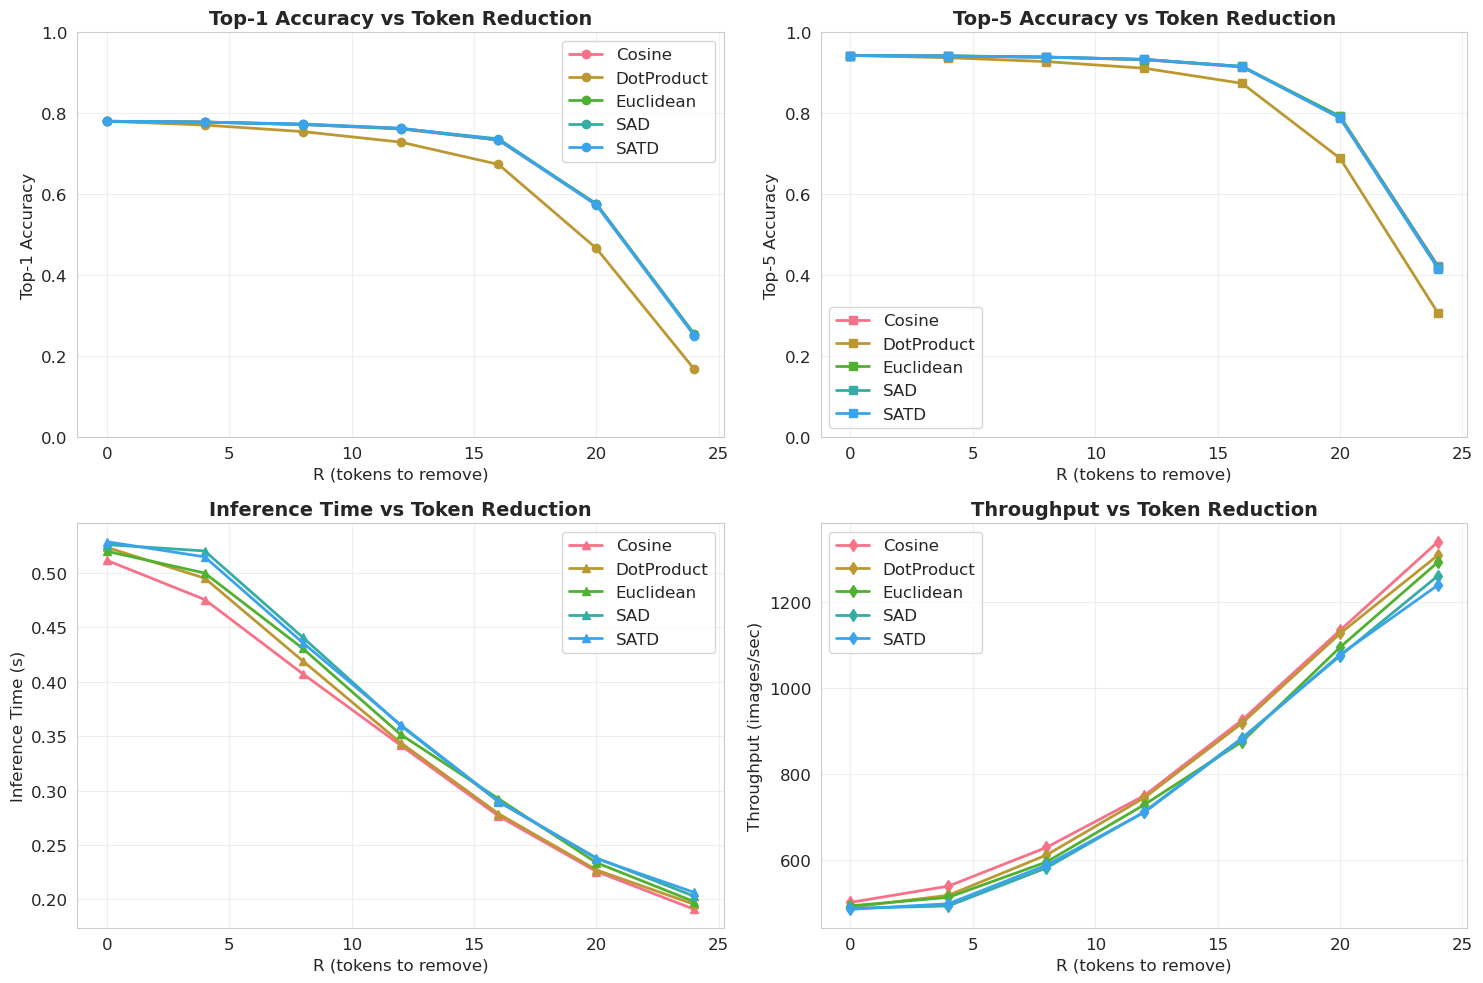

In [10]:
# 生成综合对比图（2x2布局，包含所有指标）
if 'df' in locals():
    visualizer.plot_comprehensive_comparison(
        df, 
        save_path="results/comprehensive_comparison.png"
    )
else:
    print("⚠️ 请先加载数据")

### 6.2 准确率对比图

📊 Accuracy plots saved to results/accuracy_comparison.png


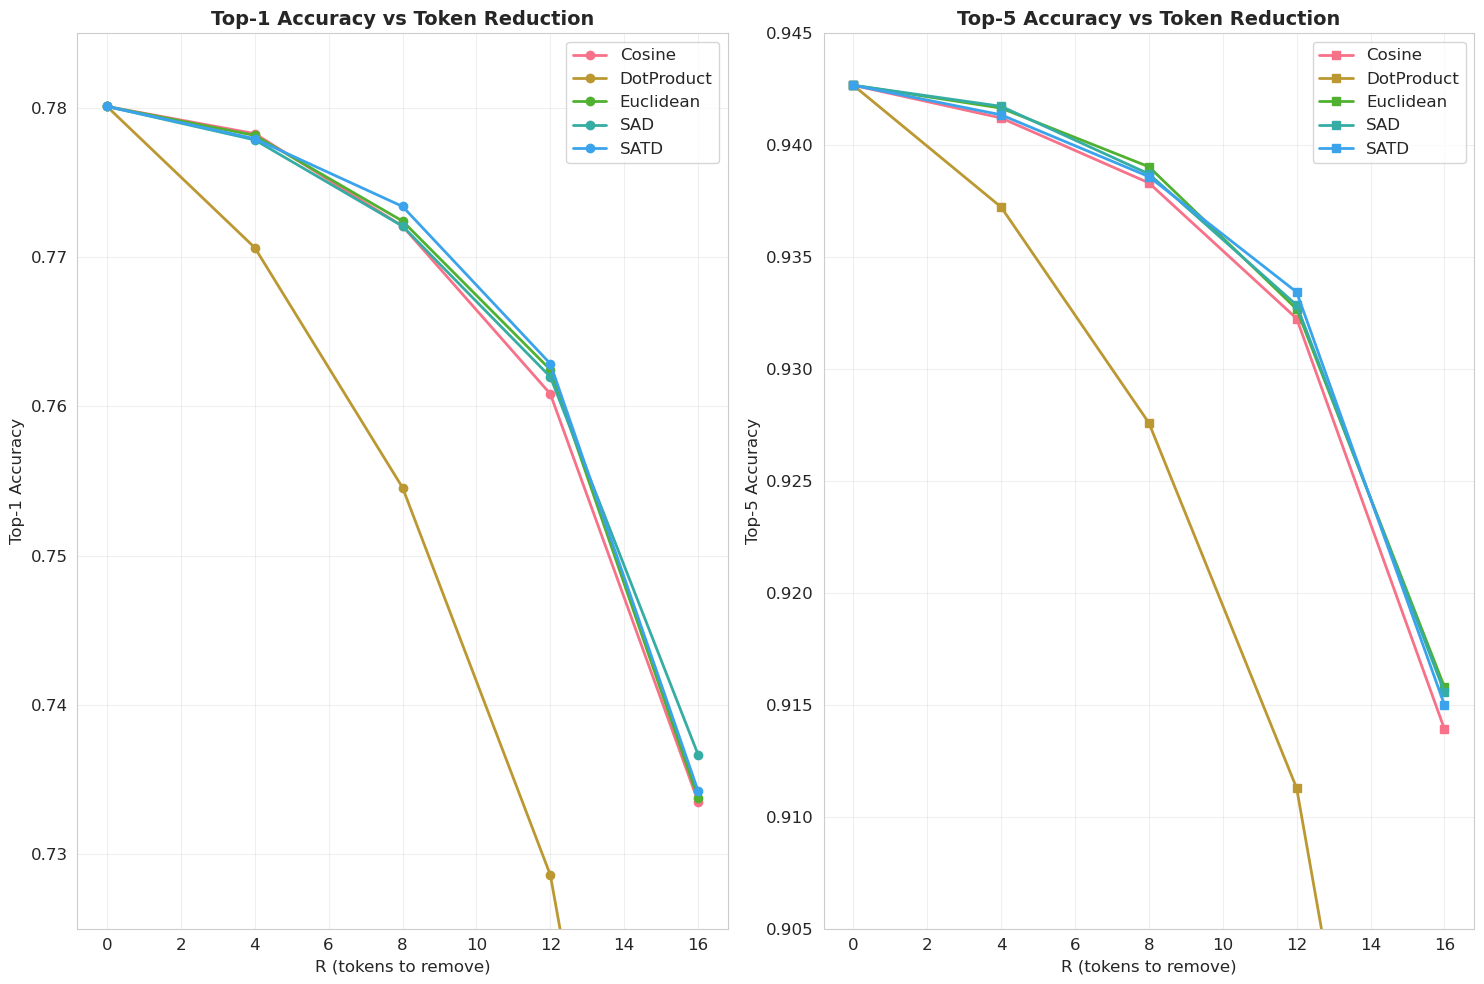

In [11]:
# 生成准确率对比图
if 'df' in locals():
    visualizer.plot_accuracy_comparison(
        df[df['R'] < 20], # 只展示R<20的数据, 
        ylim_custom=(0.725,0.785), 
        ylim_custom_2=(0.905,0.945), 
        save_path="results/accuracy_comparison.png"
    )
else:
    print("⚠️ 请先加载数据")

📊 Relative deviation plots saved to results/deviation_percentage.png


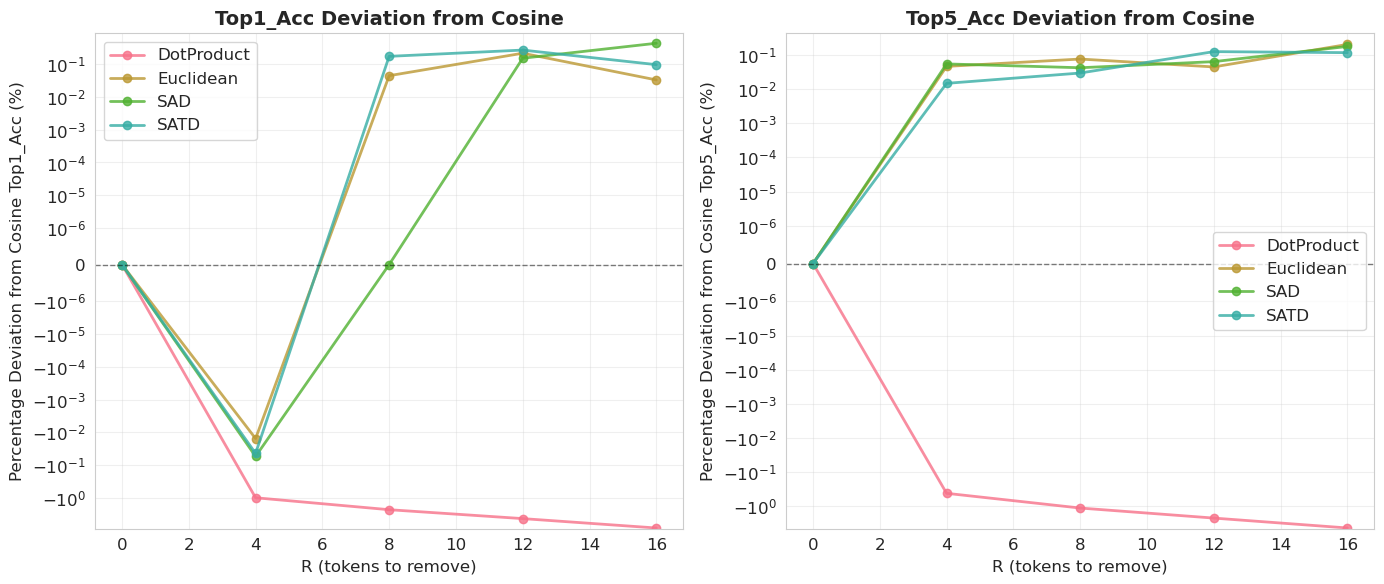

📊 Relative deviation plots saved to results/deviation_relative.png


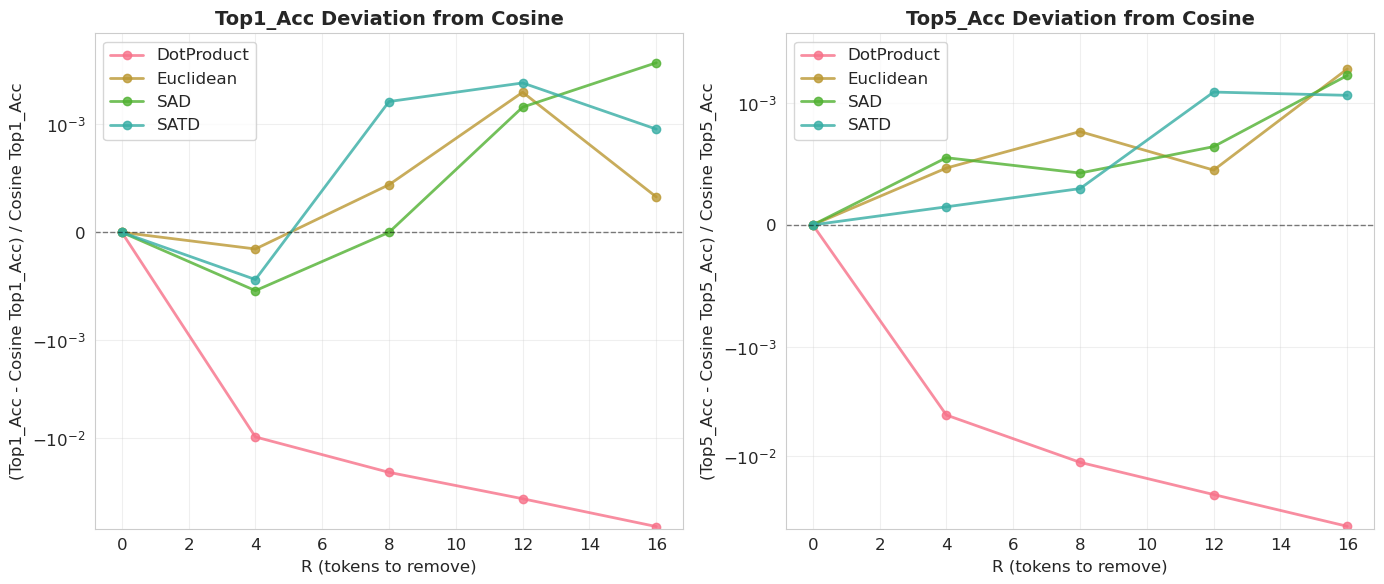

📊 Comprehensive deviation plots saved to results/comprehensive_with_deviation.png


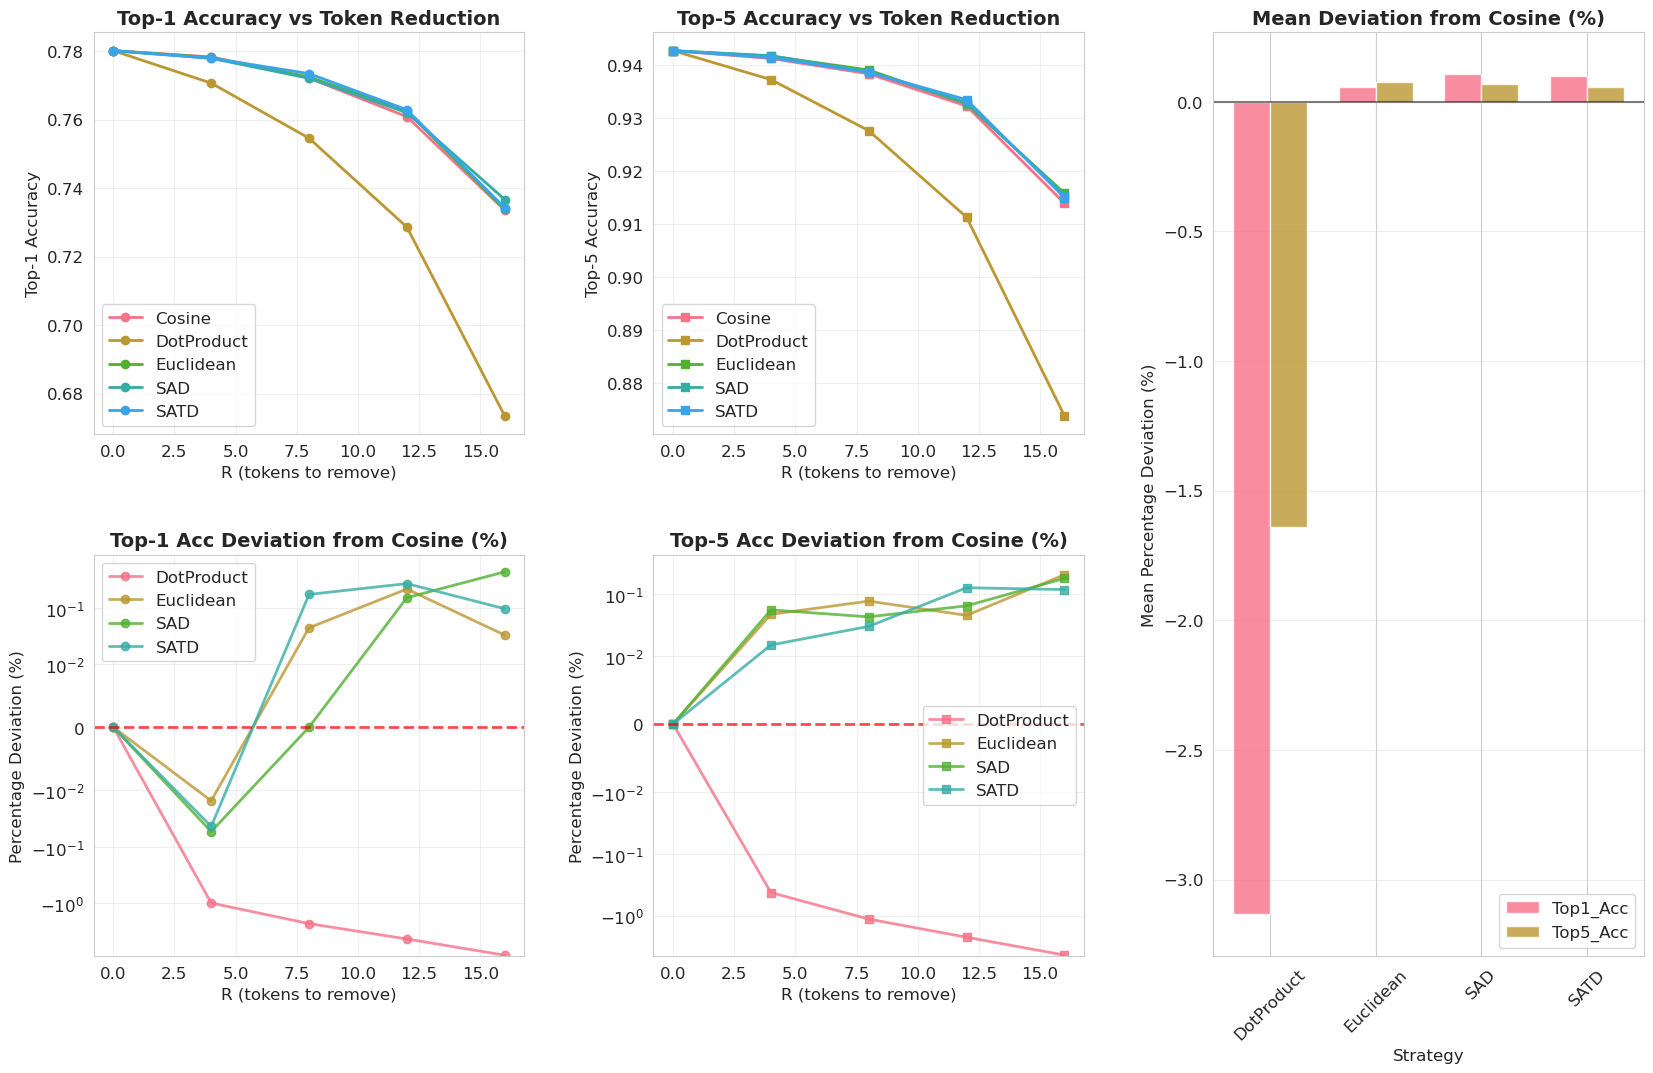

In [12]:
# 生成准确率对比图
if 'df' in locals():
    # 1. 基本相对偏差图（百分比）
    visualizer.plot_relative_deviation(
        df[df['R'] < 20], # 只展示R<20的数据, 
        baseline_strategy='Cosine',
        deviation_type='percentage',
        save_path='results/deviation_percentage.png'
    )

    # 2. 相对偏差图（相对值）
    visualizer.plot_relative_deviation(
        df[df['R'] < 20], # 只展示R<20的数据,
        baseline_strategy='Cosine',
        deviation_type='relative',
        yscale='symlog',
        threshold=0.001,
        save_path='results/deviation_relative.png'
    )

    # 3. 综合对比：原始数据 + 偏差分析
    visualizer.plot_comprehensive_with_deviation(
        df[df['R'] < 20], # 只展示R<20的数据,
        baseline_strategy='Cosine',
        save_path='results/comprehensive_with_deviation.png'
    )
else:
    print("⚠️ 请先加载数据")

### 6.3 效率对比图

📊 Efficiency plots saved to results/efficiency_comparison.png


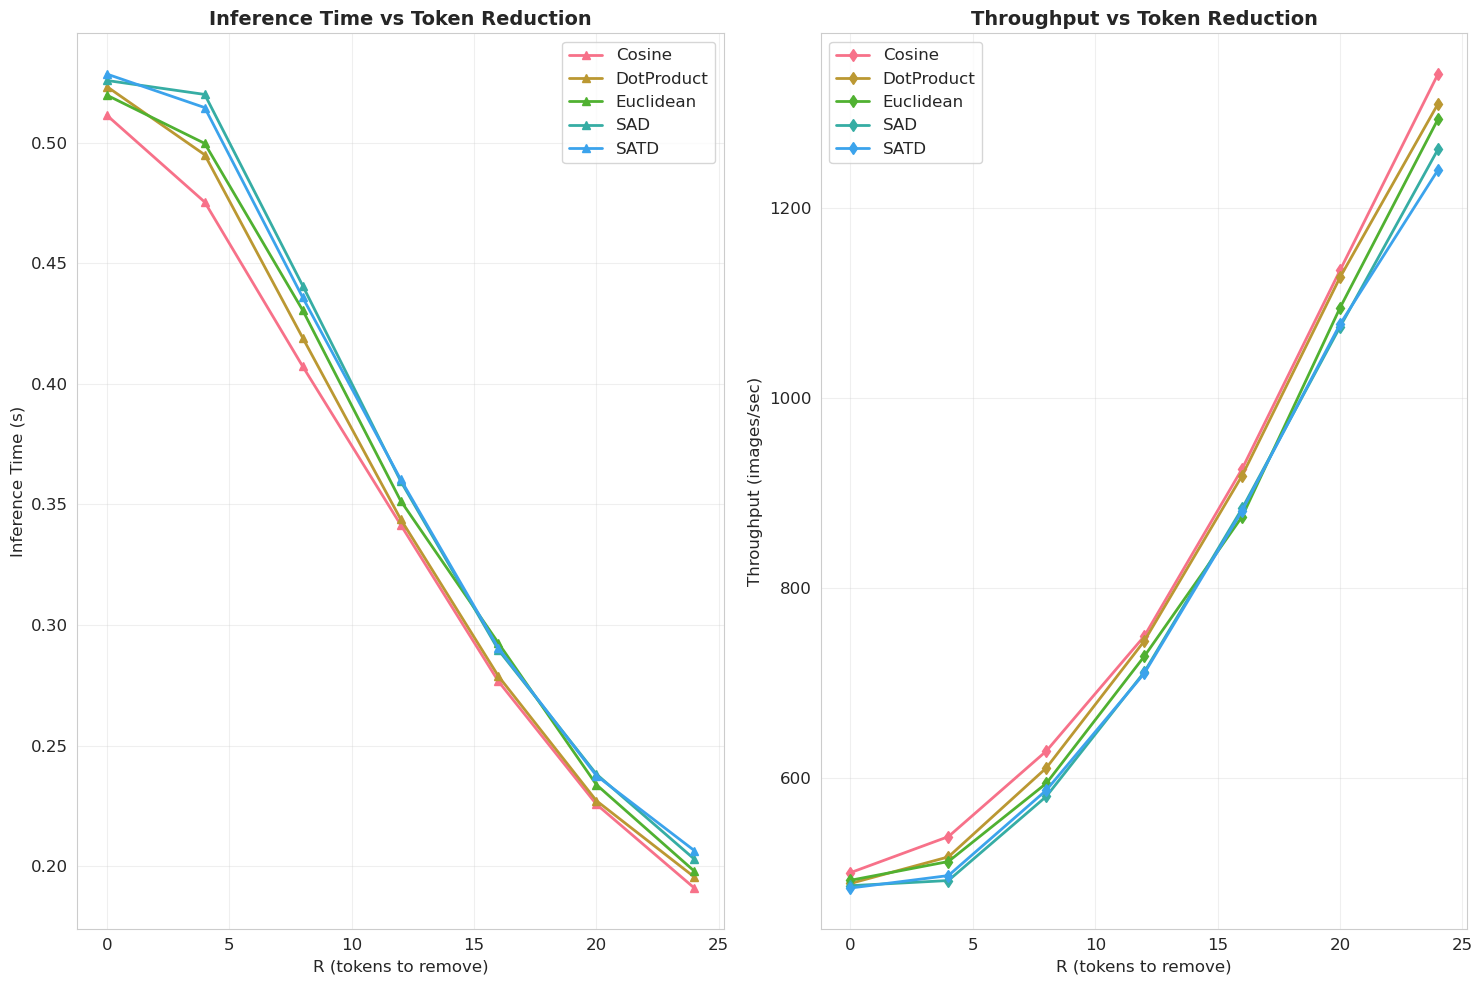

In [13]:
# 生成效率对比图
if 'df' in locals():
    visualizer.plot_efficiency_comparison(df, save_path="results/efficiency_comparison.png")
else:
    print("⚠️ 请先加载数据")

### 6.4 准确率-效率权衡图

📊 Trade-off plot saved to results/accuracy_efficiency_tradeoff.png


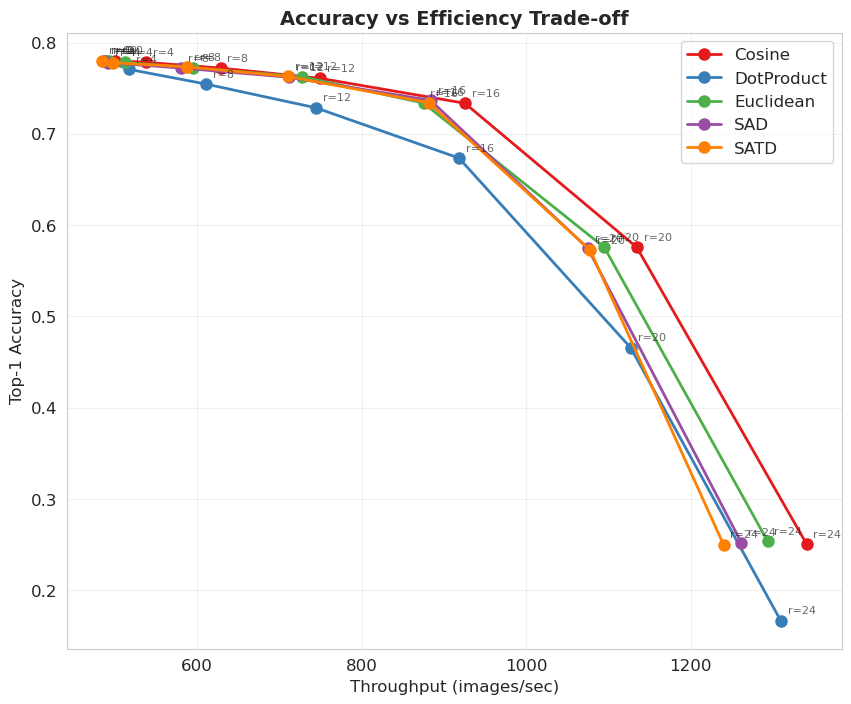

In [14]:
# 生成准确率-效率权衡图
if 'df' in locals():
    visualizer.plot_accuracy_efficiency_tradeoff(df, save_path="results/accuracy_efficiency_tradeoff.png")
else:
    print("⚠️ 请先加载数据")

### 6.5 热力图

📊 Heatmap saved to results/top1_heatmap.png


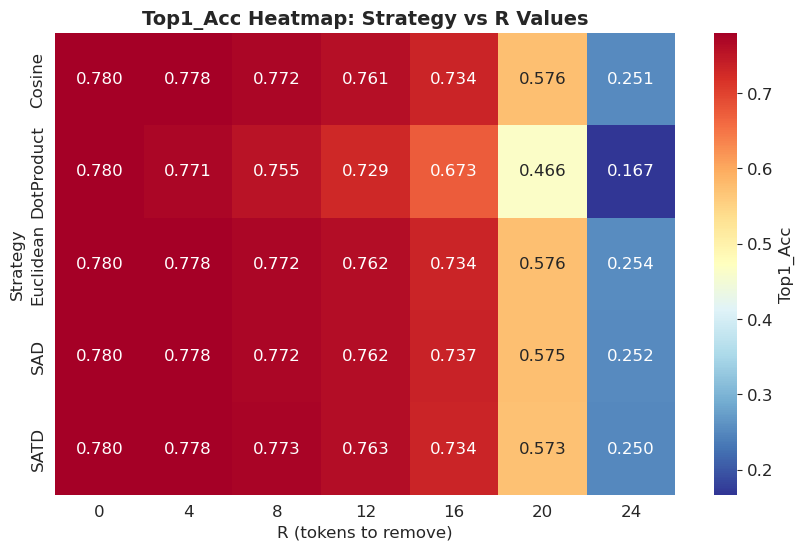

In [15]:
# 生成Top-1准确率热力图
if 'df' in locals():
    visualizer.plot_heatmap(df, metric='Top1_Acc', save_path="results/top1_heatmap.png")
else:
    print("⚠️ 请先加载数据")

📊 Heatmap saved to results/throughput_heatmap.png


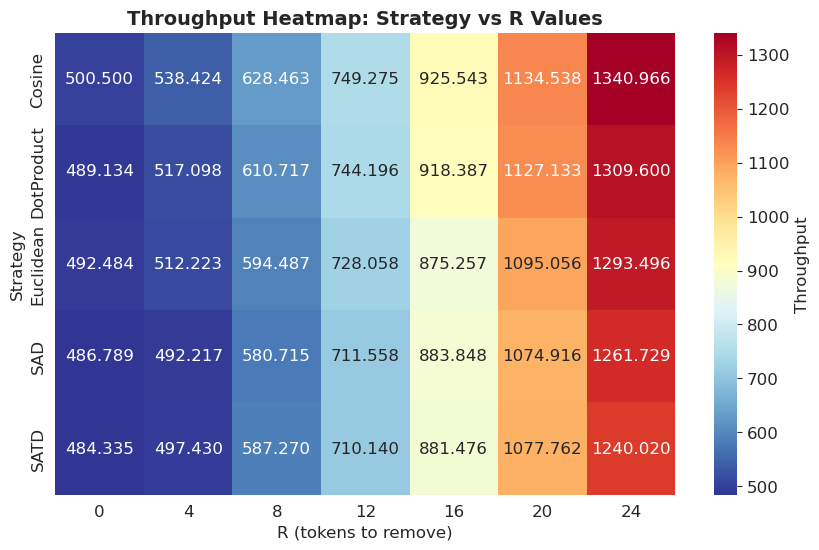

In [16]:
# 生成吞吐量热力图
if 'df' in locals() and 'Throughput' in df.columns:
    visualizer.plot_heatmap(df, metric='Throughput', save_path="results/throughput_heatmap.png")
else:
    print("⚠️ 请先加载数据或检查Throughput列是否存在")

## 7. 数据分析和汇总

In [17]:
# 找到最佳结果
if 'df' in locals():
    print("🏆 最佳结果分析:")
    print("=" * 50)
    
    # 最高Top-1准确率
    if 'Top1_Acc' in df.columns:
        best_acc_row = df.loc[df['Top1_Acc'].idxmax()]
        print(f"\n最高Top-1准确率: {best_acc_row['Top1_Acc']:.4f}")
        print(f"策略: {best_acc_row['Strategy']}, R: {best_acc_row['R']}")
    
    # 最高吞吐量
    if 'Throughput' in df.columns:
        best_thr_row = df.loc[df['Throughput'].idxmax()]
        print(f"\n最高吞吐量: {best_thr_row['Throughput']:.1f} img/s")
        print(f"策略: {best_thr_row['Strategy']}, R: {best_thr_row['R']}")
    
    # 最低推理时间
    if 'Avg_Time' in df.columns:
        best_time_row = df.loc[df['Avg_Time'].idxmin()]
        print(f"\n最低推理时间: {best_time_row['Avg_Time']:.4f}s")
        print(f"策略: {best_time_row['Strategy']}, R: {best_time_row['R']}")
    
    print("\n" + "=" * 50)
else:
    print("⚠️ 请先加载数据")

🏆 最佳结果分析:

最高Top-1准确率: 0.7801
策略: Cosine, R: 0

最高吞吐量: 1341.0 img/s
策略: Cosine, R: 24

最低推理时间: 0.1909s
策略: Cosine, R: 24



In [18]:
# 按策略汇总
if 'df' in locals():
    print("📊 按策略汇总统计:")
    print("=" * 60)
    
    summary_metrics = []
    if 'Top1_Acc' in df.columns:
        summary_metrics.append('Top1_Acc')
    if 'Top5_Acc' in df.columns:
        summary_metrics.append('Top5_Acc')
    if 'Avg_Time' in df.columns:
        summary_metrics.append('Avg_Time')
    if 'Throughput' in df.columns:
        summary_metrics.append('Throughput')
    
    if summary_metrics:
        strategy_summary = df.groupby('Strategy')[summary_metrics].agg(['mean', 'std', 'min', 'max'])
        print(strategy_summary)
    else:
        print("⚠️ 没有找到可汇总的指标列")
else:
    print("⚠️ 请先加载数据")

📊 按策略汇总统计:
            Top1_Acc                             Top5_Acc                     \
                mean       std      min     max      mean       std      min   
Strategy                                                                       
Cosine      0.664503  0.196149  0.25092  0.7801  0.840406  0.191934  0.42252   
DotProduct  0.619997  0.227387  0.16684  0.7801  0.798111  0.234502  0.30584   
Euclidean   0.665246  0.195199  0.25412  0.7801  0.840451  0.193360  0.41928   
SAD         0.665111  0.195975  0.25232  0.7801  0.840214  0.193044  0.42038   
SATD        0.664506  0.196919  0.25022  0.7801  0.839209  0.194790  0.41570   

                     Avg_Time                                Throughput  \
                max      mean       std       min       max        mean   
Strategy                                                                  
Cosine      0.94268  0.347014  0.123341  0.190907  0.511489  831.101280   
DotProduct  0.94268  0.354710  0.128984  0.19548

## 8. 导出结果

将分析结果导出为文件

In [19]:
# 导出处理后的数据和汇总统计
if 'df' in locals():
    # 确保results目录存在
    Path("results").mkdir(exist_ok=True)
    
    # 导出完整数据
    df.to_csv("results/processed_data.csv", index=False)
    print("📄 完整数据已导出到 results/processed_data.csv")
    
    # 导出汇总统计
    if 'strategy_summary' in locals():
        strategy_summary.to_csv("results/strategy_summary.csv")
        print("📄 策略汇总已导出到 results/strategy_summary.csv")
    
    # 导出最佳结果
    best_results = {}
    if 'Top1_Acc' in df.columns:
        best_acc_row = df.loc[df['Top1_Acc'].idxmax()]
        best_results['best_accuracy'] = {
            'strategy': best_acc_row['Strategy'],
            'r': int(best_acc_row['R']),
            'top1_acc': float(best_acc_row['Top1_Acc'])
        }
    
    if 'Throughput' in df.columns:
        best_thr_row = df.loc[df['Throughput'].idxmax()]
        best_results['best_throughput'] = {
            'strategy': best_thr_row['Strategy'],
            'r': int(best_thr_row['R']),
            'throughput': float(best_thr_row['Throughput'])
        }
    
    with open("results/best_results.json", 'w') as f:
        json.dump(best_results, f, indent=2)
    
    print("📄 最佳结果已导出到 results/best_results.json")
    print("✅ 所有结果已导出完成")
    
else:
    print("⚠️ 请先加载数据")

📄 完整数据已导出到 results/processed_data.csv
📄 策略汇总已导出到 results/strategy_summary.csv
📄 最佳结果已导出到 results/best_results.json
✅ 所有结果已导出完成
